# 07 — Power Analysis

This notebook reproduces the power analysis results from `scripts/06.power_analysis.py`  
using **static matplotlib/seaborn figures** rather than interactive Plotly charts.  
It is intended as a clean, reproducible record of the study's power characteristics.

**Input:** `../data/processed/survey_clean.csv`  
**Output:** `../tables/power_analysis_summary.csv`  
&emsp;&emsp;&emsp;&emsp;&emsp;`../figures/power_analysis/fig_pa1_kw_power_curve.[png|pdf]`  
&emsp;&emsp;&emsp;&emsp;&emsp;`../figures/power_analysis/fig_pa2_chisq_power_curves.[png|pdf]`  
&emsp;&emsp;&emsp;&emsp;&emsp;`../figures/power_analysis/fig_pa3_spearman_power_curves.[png|pdf]`

---

## Why power analysis?

This study enrolled **N = 18 participants** across three groups — a sample size typical  
of a **pilot / feasibility study**. Pilot studies are not designed to be definitively powered;  
their purpose is to estimate effect sizes and test procedures for a larger follow-up study.

Power analysis helps us answer two complementary questions:

1. **Sensitivity analysis** — Given the 18 participants enrolled, what is the *smallest* true  
   difference this study could reliably detect at 80% power? This is the study's minimum  
   detection threshold.

2. **Prospective sample size estimation** — Using the effect sizes observed in this pilot  
   as planning estimates, how many participants would a future adequately powered study  
   need to achieve 80% power?

> **Note on post-hoc observed power:** Computing power *from the same data used to test  
> the hypothesis* is methodologically unsound. As Hoenig & Heisey (2001) showed, observed  
> power is mathematically equivalent to a transformation of the p-value and adds no  
> independent information. This approach was deliberately avoided here.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.optimize import brentq
from scipy.stats import chi2 as chi2_dist
from scipy.stats import chi2_contingency, f as f_dist
from scipy.stats import ncf, ncx2, norm, spearmanr

warnings.filterwarnings("ignore")

# ── Theme ─────────────────────────────────────────────────────────────────────
sns.set_theme(style="white", font_scale=1.2)

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_PATH = Path("../data/processed/survey_clean.csv")
FIG_DIR   = Path("../figures/power_analysis")
TABLE_DIR = Path("../tables")
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# ── Study constants ────────────────────────────────────────────────────────────
GROUP_ORDER  = ["No Resource", "PDF", "ChatGPT"]
HUE_PALETTE  = {"No Resource": "#F8766D", "PDF": "#CD9600", "ChatGPT": "#00A9FF"}
GROUP_NS     = [7, 5, 6]          # n per group (No Resource, PDF, ChatGPT)
N_TOTAL      = 18
K_GROUPS     = 3
N_ITEMS      = 12                 # knowledge items — Bonferroni denominator
ALPHA        = 0.05
ALPHA_BONF   = ALPHA / N_ITEMS    # ≈ 0.00417
POWER_TARGET = 0.80
MAX_N        = 500

COLOR_MAIN   = "#7CAE00"          # green for all main power curves

CORRECT_COLS = [
    "c1_injury_type_correct", "c1_treatment_correct", "c1_antibiotics_correct",
    "c2_injury_type_correct", "c2_treatment_correct", "c2_tf_60min_correct",
    "c2_storage_rank_correct", "c2_antibiotics_correct",
    "c3_injury_type_correct", "c3_treatment_correct",
    "c3_imaging_correct",     "c3_antibiotics_correct",
]

# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH)
df["group_label"] = pd.Categorical(df["group_label"], categories=GROUP_ORDER, ordered=True)
print(f"Loaded {len(df)} rows. Groups: {df['group_label'].value_counts().reindex(GROUP_ORDER).to_dict()}")

Loaded 18 rows. Groups: {'No Resource': 7, 'PDF': 5, 'ChatGPT': 6}


---
## 1. Observed Effect Sizes

Three standardised effect size measures are computed — one for each test family:

| Effect size | Used for | Benchmarks (Cohen, 1988) |
|-------------|----------|--------------------------|
| **Cohen's f** | Kruskal-Wallis group comparison | small ≈ 0.10, medium ≈ 0.25, large ≈ 0.40 |
| **Cohen's w** | Per-question chi-square tests | small ≈ 0.10, medium ≈ 0.30, large ≈ 0.50 |
| **Spearman ρ** | Rank correlation (confidence vs correct) | small ≈ 0.10, medium ≈ 0.30, large ≈ 0.50 |

### Cohen's f (Kruskal-Wallis)
Derived from the one-way ANOVA F-test approximation.  
f = √(η² / (1 − η²)), where η² = SS_between / SS_total.

### Cohen's w (chi-square per question)
For each of the 12 knowledge items, a 2×3 contingency table (correct/incorrect × group)  
is formed and χ² is computed. w = √(χ² / N). The **median w** across items is used.

### Spearman ρ
Rank-order correlation between `self_confidence_mean` and `n_correct`,  
computed for all 18 participants and separately per group.

In [2]:
def _cohen_f_label(f):
    if f < 0.10: return "negligible"
    if f < 0.25: return "small"
    if f < 0.40: return "medium"
    return "large"

def _cohen_w_label(w):
    if w < 0.10: return "negligible"
    if w < 0.30: return "small"
    if w < 0.50: return "medium"
    return "large"

def _cohen_rho_label(rho):
    r = abs(rho)
    if r < 0.10: return "negligible"
    if r < 0.30: return "small"
    if r < 0.50: return "medium"
    return "large"


def compute_effect_sizes(df):
    """Compute observed effect sizes for all three test families.

    Returns a dict with keys: cohens_f, eta_sq, cohens_w_median, cohens_w_values,
    spearman_rho, spearman_pval, spearman_groups.
    """
    # A. Cohen's f — KW via one-way ANOVA approximation
    groups_data = [
        df[df["group_label"] == g]["n_correct"].dropna().values
        for g in GROUP_ORDER
    ]
    group_ns    = np.array([len(g) for g in groups_data])
    group_means = np.array([g.mean() for g in groups_data])
    grand_mean  = df["n_correct"].dropna().mean()

    ss_between = float(np.sum(group_ns * (group_means - grand_mean) ** 2))
    ss_within  = float(sum(np.sum((g - m) ** 2) for g, m in zip(groups_data, group_means)))
    ss_total   = ss_between + ss_within

    eta_sq   = ss_between / ss_total if ss_total > 0 else 0.0
    cohens_f = float(np.sqrt(eta_sq / (1.0 - eta_sq))) if 0 < eta_sq < 1 else 0.0

    # B. Cohen's w — per-question chi-square tests (2×3 tables)
    w_values = []
    for col in CORRECT_COLS:
        ct = pd.crosstab(df[col], df["group_label"])
        ct = ct.reindex(columns=GROUP_ORDER, fill_value=0)
        chi2_stat, _, _, _ = chi2_contingency(ct, correction=False)
        w_values.append(float(np.sqrt(max(chi2_stat, 0.0) / N_TOTAL)))

    # C. Spearman ρ — self-confidence vs total correct
    X_COL, Y_COL = "self_confidence_mean", "n_correct"
    valid = df[[X_COL, Y_COL]].dropna()
    rho_all, pval_all = spearmanr(valid[X_COL], valid[Y_COL])

    group_rhos = {}
    for g in GROUP_ORDER:
        sub = df[df["group_label"] == g][[X_COL, Y_COL]].dropna()
        if len(sub) >= 4:
            r, p = spearmanr(sub[X_COL], sub[Y_COL])
        else:
            r, p = float("nan"), float("nan")
        group_rhos[g] = (float(r), float(p), len(sub))

    return {
        "cohens_f":        cohens_f,
        "eta_sq":          eta_sq,
        "cohens_w_median": float(np.median(w_values)),
        "cohens_w_values": w_values,
        "spearman_rho":    float(rho_all),
        "spearman_pval":   float(pval_all),
        "spearman_groups": group_rhos,
    }


effects = compute_effect_sizes(df)

print("Observed effect sizes")
print("─" * 55)
f = effects["cohens_f"]
w = effects["cohens_w_median"]
rho = effects["spearman_rho"]
print(f"  Cohen's f  (KW, n_correct):      {f:.4f}  [{_cohen_f_label(f)}]")
print(f"  Cohen's w  (chi-sq, median):     {w:.4f}  [{_cohen_w_label(w)}]")
print(f"  Spearman ρ (all N=18):           {rho:.4f}  [p = {effects['spearman_pval']:.3f}]")
print()
for g, (r_g, p_g, n_g) in effects["spearman_groups"].items():
    p_str = f"< 0.001" if p_g < 0.001 else f"= {p_g:.3f}"
    print(f"  Spearman ρ ({g:20s}): {r_g:.4f}  [p {p_str}, n={n_g}]")

Observed effect sizes
───────────────────────────────────────────────────────
  Cohen's f  (KW, n_correct):      0.3219  [medium]
  Cohen's w  (chi-sq, median):     0.3519  [medium]
  Spearman ρ (all N=18):           0.3547  [p = 0.149]

  Spearman ρ (No Resource         ): 0.9252  [p = 0.003, n=7]
  Spearman ρ (PDF                 ): 0.2368  [p = 0.701, n=5]
  Spearman ρ (ChatGPT             ): -0.0896  [p = 0.866, n=6]


---
## 2. Power Functions

Each statistical test family uses a different power approximation:

### Kruskal-Wallis → One-way ANOVA F-test approximation
Power is computed using the **non-central F distribution** (standard practice for KW):  
- Non-centrality parameter: λ = N·f²  
- Degrees of freedom: df_num = k−1, df_denom = N−k

### Per-question chi-square → Non-central chi-square distribution
Power is computed using the **non-central χ² distribution**:  
- Non-centrality parameter: λ = N·w²  
- Degrees of freedom: df = (r−1)(c−1) = 2 for a 2×3 table

Two significance thresholds are shown:  
- **α = 0.05** (unadjusted, solid line)  
- **α ≈ 0.0042** (Bonferroni-adjusted for 12 questions, dashed line)

### Spearman correlation → Fisher z-transform approximation
Power is estimated using the **Fisher z-transform**:  
- z_ρ = arctanh(|ρ|)  
- λ = √(n−3) · z_ρ  
- Power = Φ(λ − z_crit) + Φ(−λ − z_crit)

In [3]:
# ── KW / ANOVA F-test ─────────────────────────────────────────────────────────
def _kw_power(f, n_total, k=K_GROUPS, alpha=ALPHA):
    """Power for Kruskal-Wallis (ANOVA F-test approximation, equal groups)."""
    if f <= 0 or n_total < k:
        return alpha
    df_num   = k - 1
    df_denom = n_total - k
    nc       = n_total * f ** 2
    f_crit   = f_dist.ppf(1.0 - alpha, df_num, df_denom)
    return float(1.0 - ncf.cdf(f_crit, df_num, df_denom, nc))

def _kw_required_n(f, k=K_GROUPS, alpha=ALPHA, power=POWER_TARGET):
    """Total N (equal groups) to reach target power. Returns None if > MAX_N."""
    if f <= 0.01:
        return None
    if _kw_power(f, float(MAX_N), k, alpha) < power:
        return None
    n_req = brentq(lambda n: _kw_power(f, n, k, alpha) - power, float(k * 3), float(MAX_N))
    total = int(np.ceil(n_req / k)) * k
    return total if total <= MAX_N else None

def _kw_sensitivity(alpha=ALPHA, power=POWER_TARGET):
    """Minimum detectable Cohen's f at N=18 with target power."""
    def target(f): return _kw_power(f, float(N_TOTAL), K_GROUPS, alpha) - power
    if target(0.001) >= 0:
        return 0.001
    return float(brentq(target, 0.001, 5.0))


# ── Chi-square ────────────────────────────────────────────────────────────────
def _chisq_power(w, n_total, alpha=ALPHA, df=2):
    """Power for chi-square test (2×3 table, df=2) using non-central chi-square."""
    if w <= 0:
        return alpha
    nc       = n_total * w ** 2
    chi_crit = chi2_dist.ppf(1.0 - alpha, df)
    return float(1.0 - ncx2.cdf(chi_crit, df, nc))

def _chisq_required_n(w, alpha=ALPHA, power=POWER_TARGET, df=2):
    """Total N to reach target power, chi-square test. Returns None if > MAX_N."""
    if w <= 0.01:
        return None
    if _chisq_power(w, float(MAX_N), alpha, df) < power:
        return None
    n_req = brentq(lambda n: _chisq_power(w, n, alpha, df) - power, 9.0, float(MAX_N))
    return int(np.ceil(n_req)) if int(np.ceil(n_req)) <= MAX_N else None

def _chisq_sensitivity(alpha=ALPHA, power=POWER_TARGET, df=2):
    """Minimum detectable Cohen's w at N=18 with target power."""
    def target(w): return _chisq_power(w, float(N_TOTAL), alpha, df) - power
    if target(0.001) >= 0:
        return 0.001
    return float(brentq(target, 0.001, 5.0))


# ── Spearman (Fisher z-transform) ─────────────────────────────────────────────
def _spearman_power(rho, n, alpha=ALPHA):
    """Power for two-sided H0: ρ=0, Fisher z-transform approximation."""
    if abs(rho) < 1e-6 or n <= 3:
        return alpha
    z_crit = norm.ppf(1.0 - alpha / 2.0)
    lam    = np.sqrt(n - 3) * np.arctanh(abs(rho))
    return float(norm.cdf(lam - z_crit) + norm.cdf(-lam - z_crit))

def _spearman_required_n(rho, alpha=ALPHA, power=POWER_TARGET):
    """N to reach target power (two-sided). Returns None if > MAX_N."""
    if abs(rho) < 0.01:
        return None
    if _spearman_power(rho, MAX_N, alpha) < power:
        return None
    n_req = brentq(lambda n: _spearman_power(rho, n, alpha) - power, 4.0, float(MAX_N))
    return int(np.ceil(n_req))

def _spearman_sensitivity(alpha=ALPHA, power=POWER_TARGET):
    """Minimum |ρ| detectable at N=18 with target power."""
    if _spearman_power(0.999, N_TOTAL, alpha) < power:
        return None
    return float(brentq(lambda rho: _spearman_power(rho, N_TOTAL, alpha) - power, 0.001, 0.999))


# ── Report sensitivity and required N ────────────────────────────────────────
sens_f   = _kw_sensitivity()
sens_w_u = _chisq_sensitivity(alpha=ALPHA)
sens_w_b = _chisq_sensitivity(alpha=ALPHA_BONF)
sens_rho   = _spearman_sensitivity()
sens_rho_b = _spearman_sensitivity(alpha=ALPHA_BONF)

req_kw       = _kw_required_n(effects["cohens_f"])
req_cu       = _chisq_required_n(effects["cohens_w_median"], alpha=ALPHA)
req_cb       = _chisq_required_n(effects["cohens_w_median"], alpha=ALPHA_BONF)
req_rho      = _spearman_required_n(effects["spearman_rho"])
req_rho_bonf = _spearman_required_n(effects["spearman_rho"], alpha=ALPHA_BONF)

def _fmt_n(n):
    return f"> {MAX_N}" if n is None else str(n)

print("Sensitivity (min detectable effect at N=18, 80% power)")
print("─" * 55)
print(f"  KW  min f  (α=0.05):    {sens_f:.4f}")
print(f"  Chi min w  (α=0.05):    {sens_w_u:.4f}")
print(f"  Chi min w  (Bonf):      {sens_w_b:.4f}")
print(f"  Spr min |ρ|:            {f'{sens_rho:.4f}' if sens_rho else 'not achievable at N=18'}")
print(f"  Spr min |ρ| (Bonf):     {f'{sens_rho_b:.4f}' if sens_rho_b else 'not achievable at N=18'}")
print()
print("Required N for 80% power at observed effect sizes")
print("─" * 55)
print(f"  KW  total N:            {_fmt_n(req_kw)}")
print(f"  Chi total N (α=0.05):   {_fmt_n(req_cu)}")
print(f"  Chi total N (Bonf):     {_fmt_n(req_cb)}")
print(f"  Spearman total N:       {_fmt_n(req_rho)}")
print(f"  Spearman total N (Bonf):{_fmt_n(req_rho_bonf)}")

Sensitivity (min detectable effect at N=18, 80% power)
───────────────────────────────────────────────────────
  KW  min f  (α=0.05):    0.8113
  Chi min w  (α=0.05):    0.7316
  Chi min w  (Bonf):      0.9460
  Spr min |ρ|:            0.6190
  Spr min |ρ| (Bonf):     0.7430

Required N for 80% power at observed effect sizes
───────────────────────────────────────────────────────
  KW  total N:            99
  Chi total N (α=0.05):   78
  Chi total N (Bonf):     131
  Spearman total N:       61
  Spearman total N (Bonf):103


---
## 3. Power Analysis Summary Table

The table below summarises the power analysis for each test family.  
Columns:
- **Analysis** — test type and context
- **Observed effect** — pilot-data estimate (interpret with caution given small N)
- **Effect label** — qualitative label (Cohen 1988 benchmarks)
- **Min detectable (at study n)** — smallest effect reliably detected at 80% power given the enrolled n
- **Req. total N** — participants needed in a future equal-groups study for 80% power
- **Req. n/group** — n per group for KW/chi-square rows

In [4]:
from IPython.display import display

def _n_per(total, k=K_GROUPS):
    if total is None:
        return f"> {MAX_N // k}"
    return str(int(np.ceil(total / k)))

def _sens_at_n(n_g, alpha=ALPHA):
    """Min detectable |ρ| at a specific per-group n."""
    if _spearman_power(0.999, n_g, alpha) < POWER_TARGET:
        return "not achievable"
    mde = brentq(lambda r: _spearman_power(r, n_g, alpha) - POWER_TARGET, 0.001, 0.999)
    return f"|ρ| ≥ {mde:.3f}"


rows = [
    {
        "Analysis": "Kruskal-Wallis (total correct)",
        "Test approx.": "One-way ANOVA F (k=3)",
        "Obs. effect": f"f = {effects['cohens_f']:.3f}",
        "Effect label": _cohen_f_label(effects["cohens_f"]),
        "Min detectable (at study n)": f"f ≥ {sens_f:.3f}  (N={N_TOTAL})",
        "Req. total N": _fmt_n(req_kw),
        "Req. n/group": _n_per(req_kw),
    },
    {
        "Analysis": "Chi-square per question (α=0.05)",
        "Test approx.": "χ² (df=2, 2×3 table)",
        "Obs. effect": f"w = {effects['cohens_w_median']:.3f}  (median of 12)",
        "Effect label": _cohen_w_label(effects["cohens_w_median"]),
        "Min detectable (at study n)": f"w ≥ {sens_w_u:.3f}  (N={N_TOTAL})",
        "Req. total N": _fmt_n(req_cu),
        "Req. n/group": _n_per(req_cu),
    },
    {
        "Analysis": f"Chi-square per question (α={ALPHA_BONF:.4f}, Bonferroni)",
        "Test approx.": "χ² (df=2, 2×3 table)",
        "Obs. effect": f"w = {effects['cohens_w_median']:.3f}  (median of 12)",
        "Effect label": _cohen_w_label(effects["cohens_w_median"]),
        "Min detectable (at study n)": f"w ≥ {sens_w_b:.3f}  (N={N_TOTAL})",
        "Req. total N": _fmt_n(req_cb),
        "Req. n/group": _n_per(req_cb),
    },
    {
        "Analysis": "Spearman ρ (all participants)",
        "Test approx.": "Fisher z-transform (two-sided)",
        "Obs. effect": f"ρ = {effects['spearman_rho']:.3f}",
        "Effect label": _cohen_rho_label(effects["spearman_rho"]),
        "Min detectable (at study n)": f"{_sens_at_n(N_TOTAL)}  (N={N_TOTAL})",
        "Req. total N": _fmt_n(req_rho),
        "Req. n/group": "N/A  (1 sample)",
    },
    {
        "Analysis": f"Spearman ρ (all participants, α={ALPHA_BONF:.4f} Bonferroni)",
        "Test approx.": "Fisher z-transform (two-sided)",
        "Obs. effect": f"ρ = {effects['spearman_rho']:.3f}",
        "Effect label": _cohen_rho_label(effects["spearman_rho"]),
        "Min detectable (at study n)": (f"|ρ| ≥ {sens_rho_b:.3f}  (N={N_TOTAL})"
                                         if sens_rho_b else f"not achievable  (N={N_TOTAL})"),
        "Req. total N": _fmt_n(req_rho_bonf),
        "Req. n/group": "N/A  (1 sample)",
    },
]

# Per-group Spearman rows (regular + Bonferroni)
for g, (rho_g, pval_g, n_g) in effects["spearman_groups"].items():
    if np.isnan(rho_g):
        continue
    p_str        = "p < 0.001" if pval_g < 0.001 else f"p = {pval_g:.3f}"
    req_n_g      = _spearman_required_n(rho_g)
    req_n_g_bonf = _spearman_required_n(rho_g, alpha=ALPHA_BONF)
    rows.append({
        "Analysis": f"Spearman ρ ({g})",
        "Test approx.": "Fisher z-transform (two-sided)",
        "Obs. effect": f"ρ = {rho_g:.3f}  ({p_str})",
        "Effect label": _cohen_rho_label(rho_g),
        "Min detectable (at study n)": f"{_sens_at_n(n_g)}  (n={n_g} in group)",
        "Req. total N": f"{_fmt_n(req_n_g)}  (within {g} group)",
        "Req. n/group": "—",
    })
    rows.append({
        "Analysis": f"Spearman ρ ({g}, α={ALPHA_BONF:.4f} Bonferroni)",
        "Test approx.": "Fisher z-transform (two-sided)",
        "Obs. effect": f"ρ = {rho_g:.3f}  ({p_str})",
        "Effect label": _cohen_rho_label(rho_g),
        "Min detectable (at study n)": f"{_sens_at_n(n_g, ALPHA_BONF)}  (n={n_g} in group)",
        "Req. total N": f"{_fmt_n(req_n_g_bonf)}  (within {g} group)",
        "Req. n/group": "—",
    })

summary_df = pd.DataFrame(rows)
display(summary_df)

# Export CSV
csv_path = TABLE_DIR / "power_analysis_summary.csv"
summary_df.to_csv(csv_path, index=False)
print(f"\nSaved: {csv_path}")

,Analysis,Test approx.,Obs. effect,Effect label,Min detectable (at study n),Req. total N,Req. n/group
0,Kruskal-Wallis (total correct),One-way ANOVA F (k=3),f = 0.322,medium,f ≥ 0.811 (N=18),99,33
1,Chi-square per question (α=0.05),"χ² (df=2, 2×3 table)",w = 0.352 (median of 12),medium,w ≥ 0.732 (N=18),78,26
2,"Chi-square per question (α=0.0042, Bonferroni)","χ² (df=2, 2×3 table)",w = 0.352 (median of 12),medium,w ≥ 0.946 (N=18),131,44
3,Spearman ρ (all participants),Fisher z-transform (two-sided),ρ = 0.355,medium,|ρ| ≥ 0.619 (N=18),61,N/A (1 sample)
4,"Spearman ρ (all participants, α=0.0042 Bonferr...",Fisher z-transform (two-sided),ρ = 0.355,medium,|ρ| ≥ 0.743 (N=18),103,N/A (1 sample)
5,Spearman ρ (No Resource),Fisher z-transform (two-sided),ρ = 0.925 (p = 0.003),large,|ρ| ≥ 0.886 (n=7 in group),6 (within No Resource group),—
6,"Spearman ρ (No Resource, α=0.0042 Bonferroni)",Fisher z-transform (two-sided),ρ = 0.925 (p = 0.003),large,|ρ| ≥ 0.952 (n=7 in group),9 (within No Resource group),—
7,Spearman ρ (PDF),Fisher z-transform (two-sided),ρ = 0.237 (p = 0.701),small,|ρ| ≥ 0.963 (n=5 in group),138 (within PDF group),—
8,"Spearman ρ (PDF, α=0.0042 Bonferroni)",Fisher z-transform (two-sided),ρ = 0.237 (p = 0.701),small,|ρ| ≥ 0.989 (n=5 in group),239 (within PDF group),—
9,Spearman ρ (ChatGPT),Fisher z-transform (two-sided),ρ = -0.090 (p = 0.866),negligible,|ρ| ≥ 0.924 (n=6 in group),> 500 (within ChatGPT group),—



Saved: ..\tables\power_analysis_summary.csv


---
## Figure 1 — Kruskal-Wallis Power Curve

Shows how statistical power grows with total sample size (equal groups, 3 groups)  
at the observed Cohen's f. The **dashed horizontal line** marks 80% power;  
the **dashed vertical line** marks the current N = 18.  
The annotated required N indicates the minimum total sample for 80% power in a future study.

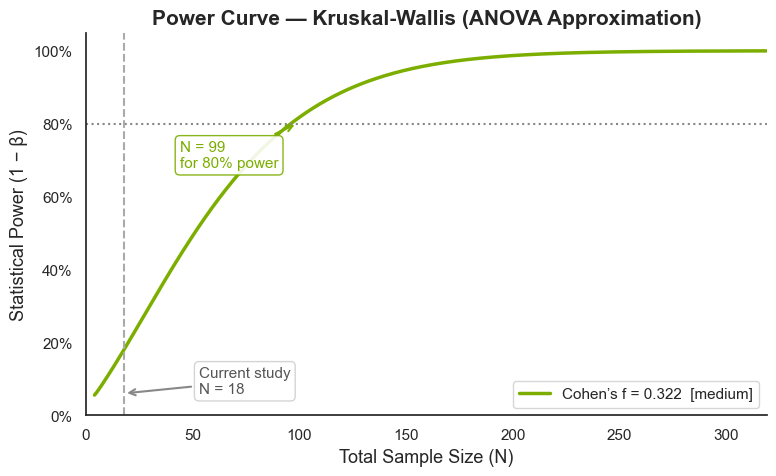

Saved fig_pa1_kw_power_curve


In [5]:
cohens_f = effects["cohens_f"]
n_req_kw = _kw_required_n(cohens_f)

# Shared x-axis range across all three figures
_all_reqs = [req_kw, req_cu, req_cb, req_rho, req_rho_bonf]
for rho_g, _, _ in effects["spearman_groups"].values():
    if not np.isnan(rho_g):
        _all_reqs.append(_spearman_required_n(rho_g))
        _all_reqs.append(_spearman_required_n(rho_g, alpha=ALPHA_BONF))
_finite = [n for n in _all_reqs if n is not None]
X_MAX = min(MAX_N, max(200, (max(_finite) if _finite else 200) + 80))

n_range = np.linspace(K_GROUPS, X_MAX, 300)
powers  = [_kw_power(cohens_f, n) for n in n_range]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(n_range, powers, color=COLOR_MAIN, linewidth=2.5,
        label=f"Cohen\u2019s f = {cohens_f:.3f}  [{_cohen_f_label(cohens_f)}]")

# Reference lines
ax.axhline(y=0.80, color="#888", linestyle=":", linewidth=1.5)
ax.axvline(x=N_TOTAL, color="#aaa", linestyle="--", linewidth=1.5)

# Current N annotation
ax.annotate(
    f"Current study\nN = {N_TOTAL}",
    xy=(N_TOTAL, 0.06), xytext=(N_TOTAL + 35, 0.06),
    arrowprops=dict(arrowstyle="->", color="#888", lw=1.5),
    fontsize=11, color="#555",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#d0d0d0", alpha=0.9),
)

# Required N annotation
if n_req_kw is not None:
    ax.annotate(
        f"N = {n_req_kw}\nfor 80% power",
        xy=(n_req_kw, 0.80), xytext=(n_req_kw - 55, 0.68),
        arrowprops=dict(arrowstyle="->", color=COLOR_MAIN, lw=1.5),
        fontsize=11, color=COLOR_MAIN,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=COLOR_MAIN, alpha=0.9),
    )

ax.set_xlim(0, X_MAX)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Total Sample Size (N)", fontsize=13)
ax.set_ylabel("Statistical Power (1 \u2212 \u03b2)", fontsize=13)
ax.set_title("Power Curve \u2014 Kruskal-Wallis (ANOVA Approximation)",
             fontsize=15, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.tick_params(labelsize=11)
ax.legend(fontsize=11, loc="lower right")
sns.despine(ax=ax)

plt.tight_layout()
fig.savefig(FIG_DIR / "fig_pa1_kw_power_curve.png", dpi=600, bbox_inches="tight", transparent=True)
fig.savefig(FIG_DIR / "fig_pa1_kw_power_curve.pdf", bbox_inches="tight")
plt.show()
print("Saved fig_pa1_kw_power_curve")

---
## Figure 2 — Chi-Square Power Curves

Shows power vs sample size for the per-question chi-square test (2×3 table, df=2)  
at the observed median Cohen's w.

- **Solid line** — unadjusted α = 0.05
- **Dashed line** — Bonferroni-adjusted α ≈ 0.0042 (0.05 ÷ 12 questions)

The Bonferroni threshold substantially increases the required sample size because  
a stricter α requires a larger effect or more data to achieve the same power.

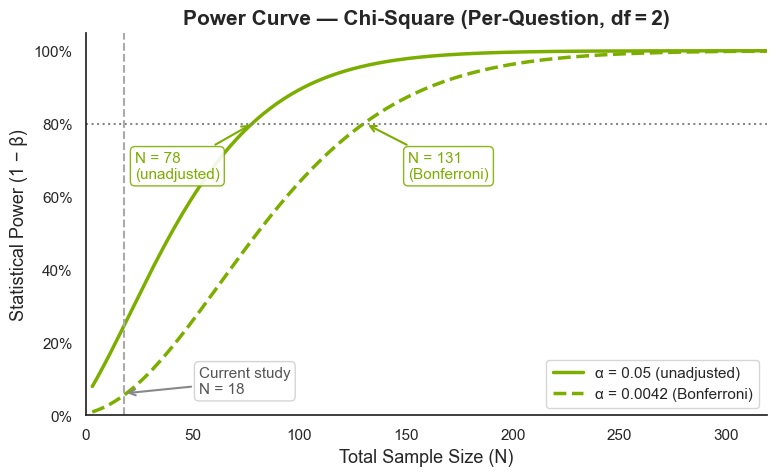

Saved fig_pa2_chisq_power_curves


In [6]:
cohens_w = effects["cohens_w_median"]

n_range       = np.linspace(3, X_MAX, 300)
powers_unadj  = [_chisq_power(cohens_w, n, alpha=ALPHA)       for n in n_range]
powers_bonf   = [_chisq_power(cohens_w, n, alpha=ALPHA_BONF)  for n in n_range]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(n_range, powers_unadj, color=COLOR_MAIN, linewidth=2.5,
        label=f"\u03b1 = 0.05 (unadjusted)")
ax.plot(n_range, powers_bonf, color=COLOR_MAIN, linewidth=2.5, linestyle="--",
        label=f"\u03b1 = {ALPHA_BONF:.4f} (Bonferroni)")

# Reference lines
ax.axhline(y=0.80, color="#888", linestyle=":", linewidth=1.5)
ax.axvline(x=N_TOTAL, color="#aaa", linestyle="--", linewidth=1.5)

# Current N annotation
ax.annotate(
    f"Current study\nN = {N_TOTAL}",
    xy=(N_TOTAL, 0.06), xytext=(N_TOTAL + 35, 0.06),
    arrowprops=dict(arrowstyle="->", color="#888", lw=1.5),
    fontsize=11, color="#555",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#d0d0d0", alpha=0.9),
)

# Required N annotations
if req_cu is not None:
    ax.annotate(
        f"N = {req_cu}\n(unadjusted)",
        xy=(req_cu, 0.80), xytext=(req_cu - 55, 0.65),
        arrowprops=dict(arrowstyle="->", color=COLOR_MAIN, lw=1.5),
        fontsize=11, color=COLOR_MAIN,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=COLOR_MAIN, alpha=0.9),
    )
if req_cb is not None:
    ax.annotate(
        f"N = {req_cb}\n(Bonferroni)",
        xy=(req_cb, 0.80), xytext=(req_cb + 20, 0.65),
        arrowprops=dict(arrowstyle="->", color=COLOR_MAIN, lw=1.5),
        fontsize=11, color=COLOR_MAIN,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=COLOR_MAIN, alpha=0.9),
    )

ax.set_xlim(0, X_MAX)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Total Sample Size (N)", fontsize=13)
ax.set_ylabel("Statistical Power (1 \u2212 \u03b2)", fontsize=13)
ax.set_title("Power Curve \u2014 Chi-Square (Per-Question, df\u202f=\u202f2)",
             fontsize=15, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.tick_params(labelsize=11)
ax.legend(fontsize=11, loc="lower right")
sns.despine(ax=ax)

plt.tight_layout()
fig.savefig(FIG_DIR / "fig_pa2_chisq_power_curves.png", dpi=600, bbox_inches="tight", transparent=True)
fig.savefig(FIG_DIR / "fig_pa2_chisq_power_curves.pdf", bbox_inches="tight")
plt.show()
print("Saved fig_pa2_chisq_power_curves")

---
## Figure 3 — Spearman Correlation Power Curves

Shows power vs sample size for the Spearman rank-order correlation  
(Fisher z-transform approximation).

- **Solid lines** — α = 0.05 (green = all participants; coloured = per group)
- **Dotted lines** — Bonferroni-corrected α ≈ 0.0042 (same colour scheme)
- Per-group curves are based on very small subsamples (n = 5–7) and should be  
  interpreted with particular caution.

The x-axis represents the sample size for that subset (total N for the solid line,  
within-group n for dotted lines).

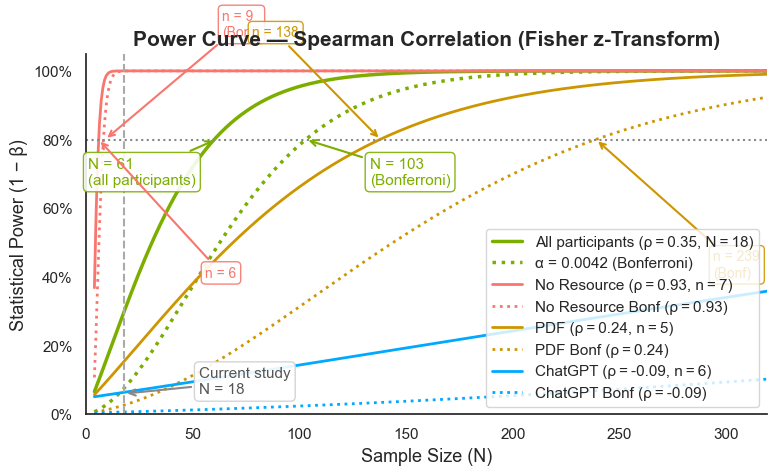

Saved fig_pa3_spearman_power_curves


In [7]:
rho_all     = effects["spearman_rho"]
group_rhos  = effects["spearman_groups"]
req_rho_all = _spearman_required_n(rho_all)

n_range_spr = np.linspace(4, X_MAX, 400)

fig, ax = plt.subplots(figsize=(8, 5))

# All-participants curve (solid green)
powers_all = [_spearman_power(rho_all, n) for n in n_range_spr]
ax.plot(n_range_spr, powers_all, color=COLOR_MAIN, linewidth=2.5,
        label=f"All participants (\u03c1\u202f=\u202f{rho_all:.2f}, N\u202f=\u202f18)")

# All-participants Bonferroni curve (dotted green)
powers_all_bonf = [_spearman_power(rho_all, n, alpha=ALPHA_BONF) for n in n_range_spr]
ax.plot(n_range_spr, powers_all_bonf, color=COLOR_MAIN, linewidth=2.5, linestyle=":",
        label=f"\u03b1 = {ALPHA_BONF:.4f} (Bonferroni)")

# Per-group curves (solid = α=0.05, dotted = Bonferroni)
for g, (rho_g, pval_g, n_g) in group_rhos.items():
    if np.isnan(rho_g):
        continue
    color    = HUE_PALETTE[g]
    powers_g = [_spearman_power(rho_g, n) for n in n_range_spr]
    ax.plot(n_range_spr, powers_g, color=color, linewidth=2,
            label=f"{g} (\u03c1\u202f=\u202f{rho_g:.2f}, n\u202f=\u202f{n_g})")
    powers_g_bonf = [_spearman_power(rho_g, n, alpha=ALPHA_BONF) for n in n_range_spr]
    ax.plot(n_range_spr, powers_g_bonf, color=color, linewidth=2, linestyle=":",
            label=f"{g} Bonf (\u03c1\u202f=\u202f{rho_g:.2f})")

# Reference lines
ax.axhline(y=0.80, color="#888", linestyle=":", linewidth=1.5)
ax.axvline(x=N_TOTAL, color="#aaa", linestyle="--", linewidth=1.5)

# Current N annotation
ax.annotate(
    f"Current study\nN = {N_TOTAL}",
    xy=(N_TOTAL, 0.06), xytext=(N_TOTAL + 35, 0.06),
    arrowprops=dict(arrowstyle="->", color="#888", lw=1.5),
    fontsize=11, color="#555",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#d0d0d0", alpha=0.9),
)

# Required N annotation for overall curve
if req_rho_all is not None:
    ax.annotate(
        f"N = {req_rho_all}\n(all participants)",
        xy=(req_rho_all, 0.80), xytext=(req_rho_all - 60, 0.67),
        arrowprops=dict(arrowstyle="->", color=COLOR_MAIN, lw=1.5),
        fontsize=11, color=COLOR_MAIN,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=COLOR_MAIN, alpha=0.9),
    )

# Required N annotation for Bonferroni overall curve
if req_rho_bonf is not None:
    ax.annotate(
        f"N = {req_rho_bonf}\n(Bonferroni)",
        xy=(req_rho_bonf, 0.80), xytext=(req_rho_bonf + 30, 0.67),
        arrowprops=dict(arrowstyle="->", color=COLOR_MAIN, lw=1.5),
        fontsize=11, color=COLOR_MAIN,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=COLOR_MAIN, alpha=0.9),
    )

# Per-group required N annotations (regular + Bonferroni)
_grp_annot_offsets = {
    "No Resource": (50, -40),
    "PDF":         (-60, 30),
    "ChatGPT":     (-60, -50),
}
_grp_annot_offsets_bonf = {
    "No Resource": (55, 30),
    "PDF":         (55, -40),
    "ChatGPT":     (55, -50),
}
for g, (rho_g, _, n_g) in group_rhos.items():
    if np.isnan(rho_g):
        continue
    color = HUE_PALETTE[g]
    req_g = _spearman_required_n(rho_g)
    if req_g is not None:
        dx, dy = _grp_annot_offsets.get(g, (-55, -40))
        ax.annotate(
            f"n = {req_g}", xy=(req_g, 0.80), xytext=(req_g + dx, 0.80 + dy / 100),
            arrowprops=dict(arrowstyle="->", color=color, lw=1.5),
            fontsize=10, color=color,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=color, alpha=0.9),
        )
    req_gb = _spearman_required_n(rho_g, alpha=ALPHA_BONF)
    if req_gb is not None:
        dx, dy = _grp_annot_offsets_bonf.get(g, (55, -40))
        ax.annotate(
            f"n = {req_gb}\n(Bonf)", xy=(req_gb, 0.80), xytext=(req_gb + dx, 0.80 + dy / 100),
            arrowprops=dict(arrowstyle="->", color=color, lw=1.5),
            fontsize=10, color=color,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=color, alpha=0.9),
        )

ax.set_xlim(0, X_MAX)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Sample Size (N)", fontsize=13)
ax.set_ylabel("Statistical Power (1 \u2212 \u03b2)", fontsize=13)
ax.set_title("Power Curve \u2014 Spearman Correlation (Fisher z-Transform)",
             fontsize=15, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.tick_params(labelsize=11)
ax.legend(fontsize=11, loc="lower right")
sns.despine(ax=ax)

plt.tight_layout()
fig.savefig(FIG_DIR / "fig_pa3_spearman_power_curves.png", dpi=600, bbox_inches="tight", transparent=True)
fig.savefig(FIG_DIR / "fig_pa3_spearman_power_curves.pdf", bbox_inches="tight")
plt.show()
print("Saved fig_pa3_spearman_power_curves")